# Environment Setup & Local CUDA Verification

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

# Enforce strict reproducibility via Random Seed 7
SEED = 7
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"[SUCCESS] CUDA is connected locally on: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("[WARNING] CUDA is not available. Running execution on CPU.")

[SUCCESS] CUDA is connected locally on: NVIDIA GeForce RTX 4060 Laptop GPU


# Cell 2: Tiny Shakespeare Dataset Fetching & Vocabulary Pipeline

In [2]:
# Automatically download Tiny Shakespeare dataset to local workspace
data_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
data_path = "tinyshakespeare.txt"

if not os.path.exists(data_path):
    print("[INFO] Downloading Tiny Shakespeare dataset...")
    urllib.request.urlretrieve(data_url, data_path)
    print("[SUCCESS] Dataset downloaded successfully.")

with open(data_path, 'r', encoding='utf-8') as f:
    text_data = f.read()

print(f"Total Dataset Size: {len(text_data)} characters")

# Construct character-to-index and index-to-character maps
unique_chars = sorted(list(set(text_data)))
vocab_size = len(unique_chars)
char_to_idx = {char: idx for idx, char in enumerate(unique_chars)}
idx_to_char = {idx: char for idx, char in enumerate(unique_chars)}

print(f"Vocabulary Size: {vocab_size} unique characters")

# Explicit, statistically sound 80% Train / 20% Validation split
split_idx = int(len(text_data) * 0.8)
train_text = text_data[:split_idx]
val_text = text_data[split_idx:]

class ShakespeareDataset(Dataset):
    def __init__(self, text, seq_len, char_to_idx):
        self.text = text
        self.seq_len = seq_len
        self.char_to_idx = char_to_idx

    def __len__(self):
        return len(self.text) - self.seq_len

    def __getitem__(self, idx):
        input_seq = self.text[idx : idx + self.seq_len]
        target_seq = self.text[idx + 1 : idx + self.seq_len + 1]
        
        x = torch.tensor([self.char_to_idx[c] for c in input_seq], dtype=torch.long)
        y = torch.tensor([self.char_to_idx[c] for c in target_seq], dtype=torch.long)
        return x, y

[INFO] Downloading Tiny Shakespeare dataset...
[SUCCESS] Dataset downloaded successfully.
Total Dataset Size: 1115394 characters
Vocabulary Size: 65 unique characters


# Cell 3: Causal Transformer Architecture & FLOP Estimator

In [3]:
class ShakespeareTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, max_seq_len=100, dropout=0.1):
        super().__init__()
        self.token_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.position_embeddings = nn.Embedding(max_seq_len, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer_blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.lm_head = nn.Linear(embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len = x.size()
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        x_embeddings = self.token_embeddings(x) + self.position_embeddings(positions)
        x_embeddings = self.dropout(x_embeddings)
        
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len, device=x.device)
        transformer_out = self.transformer_blocks(x_embeddings, mask=causal_mask, is_causal=True)
        logits = self.lm_head(transformer_out)
        return logits

def estimate_transformer_flops(seq_len, vocab_size, embed_dim, num_layers, batch_size=1):
    qkv_flops = 3 * 2 * seq_len * (embed_dim ** 2)
    attn_matrix_flops = 2 * (seq_len ** 2) * embed_dim
    attn_weighted_flops = 2 * (seq_len ** 2) * embed_dim
    attn_out_flops = 2 * seq_len * (embed_dim ** 2)
    
    total_mha_flops = qkv_flops + attn_matrix_flops + attn_weighted_flops + attn_out_flops
    ffn_flops = 16 * seq_len * (embed_dim ** 2)
    lm_head_flops = 2 * seq_len * embed_dim * vocab_size
    
    total_flops_per_layer = (total_mha_flops + ffn_flops) * num_layers
    total_forward_flops = batch_size * (total_flops_per_layer + lm_head_flops)
    return total_forward_flops

# Cell 4

In [4]:
def generate_text_sample(model, start_str, length, char_to_idx, idx_to_char, max_seq_len=100):
    model.eval()
    generated = start_str
    with torch.no_grad():
        for _ in range(length):
            context_str = generated[-max_seq_len:]
            input_tokens = [char_to_idx[c] for c in context_str if c in char_to_idx]
            if not input_tokens:
                break
            x = torch.tensor([input_tokens], dtype=torch.long, device=device)
            logits = model(x)
            next_token_logits = logits[0, -1, :]
            probs = torch.softmax(next_token_logits / 0.8, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1).item()
            generated += idx_to_char[next_idx]
    return generated

def train_eval_shakespeare(model, train_loader, val_loader, epochs=1, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    train_loss_history, val_loss_history = [], []
    total_train_start = time.time()

    for epoch in range(epochs):                      # <-- FIX: epochs now actually loop
        model.train()
        running_train_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits.view(-1, vocab_size), y_batch.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_train_loss += loss.item() * x_batch.size(0)
        train_loss_history.append(running_train_loss / len(train_loader.dataset))

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val, y_val = x_val.to(device), y_val.to(device)
                logits = model(x_val)
                loss = criterion(logits.view(-1, vocab_size), y_val.view(-1))
                running_val_loss += loss.item() * x_val.size(0)
        val_loss_history.append(running_val_loss / len(val_loader.dataset))

    total_train_time = time.time() - total_train_start

    # Final-epoch accuracy + inference latency pass
    model.eval()
    correct_tokens, total_tokens = 0, 0
    inference_times = []
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            inf_start = time.time()
            logits = model(x_val)
            if device.type == "cuda":
                torch.cuda.synchronize()
            inference_times.append((time.time() - inf_start) * 1000)
            predictions = torch.argmax(logits, dim=-1)
            correct_tokens += (predictions == y_val).sum().item()
            total_tokens += y_val.numel()

    val_accuracy = correct_tokens / total_tokens
    avg_inference_latency_ms = np.mean(inference_times)

    return train_loss_history, val_loss_history, val_accuracy, total_train_time, avg_inference_latency_ms

# Cell 5

[RUNNING] P1_Seq20 -> Seq:20 | Blk:2 | Hd:2 | Dim:64 | Data:full | Epochs:5


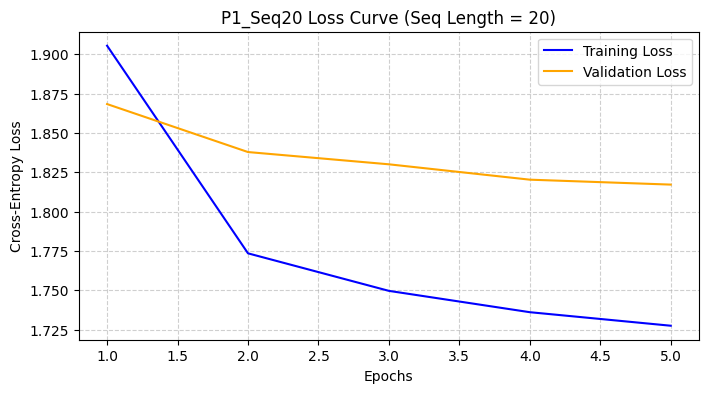

[RUNNING] P1_Seq30 -> Seq:30 | Blk:2 | Hd:2 | Dim:64 | Data:full | Epochs:5


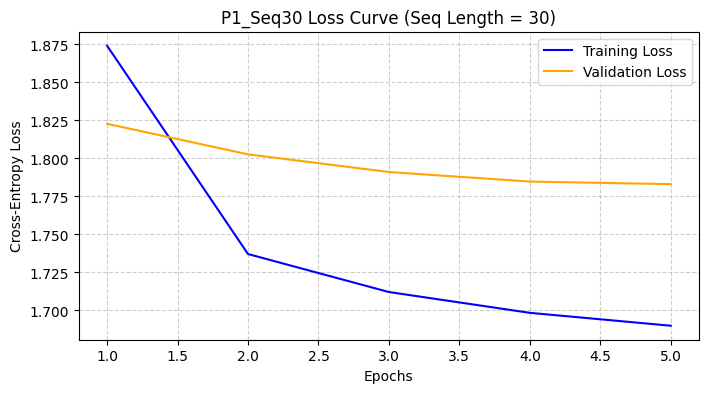

[RUNNING] P2_Config1 -> Seq:30 | Blk:1 | Hd:2 | Dim:32 | Data:subset | Epochs:5
[RUNNING] P2_Config2 -> Seq:30 | Blk:1 | Hd:4 | Dim:32 | Data:subset | Epochs:5
[RUNNING] P2_Config3 -> Seq:30 | Blk:2 | Hd:2 | Dim:32 | Data:subset | Epochs:5
[RUNNING] P2_Config4 -> Seq:30 | Blk:2 | Hd:4 | Dim:32 | Data:subset | Epochs:5
[RUNNING] P2_Config5 -> Seq:30 | Blk:4 | Hd:2 | Dim:32 | Data:subset | Epochs:5
[RUNNING] P2_Config6 -> Seq:30 | Blk:4 | Hd:4 | Dim:32 | Data:subset | Epochs:5
[RUNNING] P3_Seq50 -> Seq:50 | Blk:2 | Hd:2 | Dim:64 | Data:full | Epochs:5


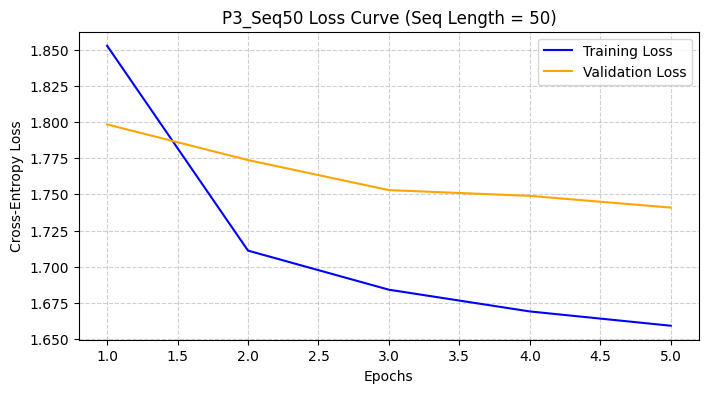


Phase        | TrainLoss | ValLoss  | PPL     | Acc%   | TrainT(s) | InfT(ms) | Params   | Sample
P1_Seq20     | 1.7275    | 1.8172   | 6.15    | 47.01  | 645.32    | 1.44     | 114753   | ROMEO: The love much d dne ch f pe ...
P1_Seq30     | 1.6899    | 1.7831   | 5.95    | 47.89  | 663.46    | 1.45     | 114753   | ROMEO: Then with that I'll thateakn...
P2_Config1   | 2.0292    | 2.3872   | 10.88   | 36.55  | 52.01     | 1.1      | 20129    | ROMEO: Tent: Or with havere wou me ...
P2_Config2   | 2.0059    | 2.3622   | 10.61   | 37.31  | 52.8      | 0.93     | 20129    | ROMEO: Fill the the ent moth thilea...
P2_Config3   | 1.9168    | 2.28     | 9.78    | 39.37  | 70.97     | 1.33     | 32833    | ROMEO: We a not words love you, mes...
P2_Config4   | 1.91      | 2.2835   | 9.81    | 39.08  | 72.5      | 1.53     | 32833    | ROMEO: He by mother stall him w s d...
P2_Config5   | 1.8215    | 2.2691   | 9.67    | 40.32  | 107.99    | 2.17     | 58241    | ROMEO: I and we home cont The 

In [5]:
# P1 baseline + P3 stretch run on the FULL dataset (only 3 runs, cheap enough)
# 6-combo sweep uses a subset to keep total sweep time reasonable — stated assumption in report
TRAIN_SUBSET_SIZE = 100000
VAL_SUBSET_SIZE = 20000
train_subset = train_text[:TRAIN_SUBSET_SIZE]
val_subset = val_text[:VAL_SUBSET_SIZE]

BATCH_SIZE = 64
EPOCHS_MAIN = 5   # was silently 1 before the fix — raise this if your GPU time allows more
EPOCHS_SWEEP = 5

# (phase, seq_len, blocks, heads, hidden_dim, use_full_data, epochs)
execution_plan = [
    ("P1_Seq20", 20, 2, 2, 64, True,  EPOCHS_MAIN),
    ("P1_Seq30", 30, 2, 2, 64, True,  EPOCHS_MAIN),

    # 6-combination sweep (1,2,4 blocks x 2,4 heads), fixed seq_len=30, subset data
    ("P2_Config1", 30, 1, 2, 32, False, EPOCHS_SWEEP),
    ("P2_Config2", 30, 1, 4, 32, False, EPOCHS_SWEEP),
    ("P2_Config3", 30, 2, 2, 32, False, EPOCHS_SWEEP),
    ("P2_Config4", 30, 2, 4, 32, False, EPOCHS_SWEEP),
    ("P2_Config5", 30, 4, 2, 32, False, EPOCHS_SWEEP),
    ("P2_Config6", 30, 4, 4, 32, False, EPOCHS_SWEEP),

    ("P3_Seq50", 50, 2, 2, 64, True, EPOCHS_MAIN),
]

shakespeare_results = {}
for phase, seq_len, blocks, heads, hidden_dim, use_full, epochs in execution_plan:
    src_train = train_text if use_full else train_subset
    src_val = val_text if use_full else val_subset
    print(f"[RUNNING] {phase} -> Seq:{seq_len} | Blk:{blocks} | Hd:{heads} | Dim:{hidden_dim} | "
          f"Data:{'full' if use_full else 'subset'} | Epochs:{epochs}")

    train_dataset = ShakespeareDataset(src_train, seq_len, char_to_idx)
    val_dataset = ShakespeareDataset(src_val, seq_len, char_to_idx)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    torch.manual_seed(SEED)
    model = ShakespeareTransformer(
        vocab_size=vocab_size, embed_dim=hidden_dim, num_heads=heads,
        num_layers=blocks, max_seq_len=100
    ).to(device)

    param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    flop_count = estimate_transformer_flops(seq_len, vocab_size, hidden_dim, blocks, batch_size=1)

    t_hist, v_hist, v_acc, train_time, inf_time = train_eval_shakespeare(
        model, train_loader, val_loader, epochs=epochs
    )
    val_ppl = np.exp(v_hist[-1])
    sample = generate_text_sample(model, "ROMEO:\n", 50, char_to_idx, idx_to_char)

    shakespeare_results[phase] = {
        "Train Loss": round(t_hist[-1], 4), "Val Loss": round(v_hist[-1], 4),
        "Val PPL": round(val_ppl, 2), "Val Acc %": round(v_acc * 100, 2),
        "Train T(s)": round(train_time, 2), "Inf T(ms)": round(inf_time, 2),
        "Params": param_count, "FLOPs": flop_count,
        "Train Hist": t_hist, "Val Hist": v_hist,
        "Sample": sample.replace('\n', ' ')
    }

    # Loss curve for the P1/P3 required-comparison runs (matches Problem 1's plotting style)
    if phase.startswith("P1") or phase.startswith("P3"):
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, epochs + 1), t_hist, label='Training Loss', color='blue')
        plt.plot(range(1, epochs + 1), v_hist, label='Validation Loss', color='orange')
        plt.title(f'{phase} Loss Curve (Seq Length = {seq_len})')
        plt.xlabel('Epochs'); plt.ylabel('Cross-Entropy Loss')
        plt.grid(True, linestyle='--', alpha=0.6); plt.legend()
        plt.show()

print("\n" + "="*140)
print(f"{'Phase':<12} | {'TrainLoss':<9} | {'ValLoss':<8} | {'PPL':<7} | {'Acc%':<6} | {'TrainT(s)':<9} | {'InfT(ms)':<8} | {'Params':<8} | {'Sample'}")
print("="*140)
for phase, d in shakespeare_results.items():
    print(f"{phase:<12} | {d['Train Loss']:<9} | {d['Val Loss']:<8} | {d['Val PPL']:<7} | {d['Val Acc %']:<6} | {d['Train T(s)']:<9} | {d['Inf T(ms)']:<8} | {d['Params']:<8} | {d['Sample'][:35]}...")

# FLOP visualization

In [6]:
configs_used = [
    ("P1_Seq20", 20, 2, 64), ("P1_Seq30", 30, 2, 64),
    ("P2_Config1", 30, 1, 32), ("P2_Config2", 30, 1, 32),
    ("P2_Config3", 30, 2, 32), ("P2_Config4", 30, 2, 32),
    ("P2_Config5", 30, 4, 32), ("P2_Config6", 30, 4, 32),
    ("P3_Seq50", 50, 2, 64),
]
print(f"{'Phase':<12} | {'FLOPs':<15}")
for phase, seq_len, blocks, hidden in configs_used:
    flops = estimate_transformer_flops(seq_len, vocab_size, hidden, blocks, batch_size=1)
    print(f"{phase:<12} | {flops:<15,}")

Phase        | FLOPs          
P1_Seq20     | 4,303,360      
P1_Seq30     | 6,608,640      
P2_Config1   | 977,280        
P2_Config2   | 977,280        
P2_Config3   | 1,829,760      
P2_Config4   | 1,829,760      
P2_Config5   | 3,534,720      
P2_Config6   | 3,534,720      
P3_Seq50     | 11,526,400     


# Architecture Analysis Chart

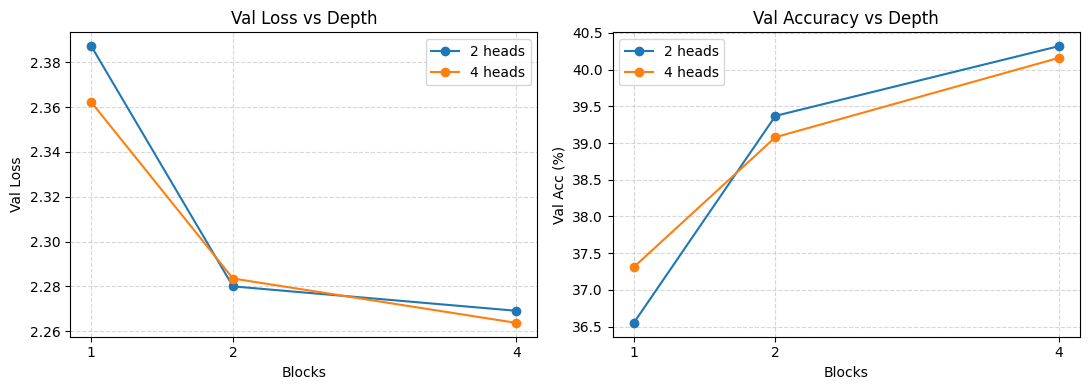

In [7]:
config_map = {"P2_Config1": (1,2), "P2_Config2": (1,4), "P2_Config3": (2,2),
              "P2_Config4": (2,4), "P2_Config5": (4,2), "P2_Config6": (4,4)}
blocks_list = [1, 2, 4]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for heads in [2, 4]:
    vals = [shakespeare_results[p]["Val Loss"] for p,(b,h) in config_map.items() if h==heads]
    accs = [shakespeare_results[p]["Val Acc %"] for p,(b,h) in config_map.items() if h==heads]
    axes[0].plot(blocks_list, vals, marker='o', label=f'{heads} heads')
    axes[1].plot(blocks_list, accs, marker='o', label=f'{heads} heads')
axes[0].set_xlabel('Blocks'); axes[0].set_ylabel('Val Loss'); axes[0].legend(); axes[0].set_title('Val Loss vs Depth')
axes[1].set_xlabel('Blocks'); axes[1].set_ylabel('Val Acc (%)'); axes[1].legend(); axes[1].set_title('Val Accuracy vs Depth')
for ax in axes: ax.set_xticks(blocks_list); ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()